In [1]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [2]:
from data import constants
import pandas as pd
import os
import numpy as np

In [3]:
def parse_capnostream(name: str):
    file_path = os.path.join(constants.raw_data_dir, "package", name)
    raw_capnostream_df = pd.read_excel(file_path)
    data_start_row = 6
    waveform_extracted_time = raw_capnostream_df.iloc[data_start_row:, 1].reset_index(drop=True)
    waveform_extracted_value = raw_capnostream_df.iloc[data_start_row:, 2].reset_index(drop=True).map(lambda x: float(x) if isinstance(x, (int, float)) else -1)
    co2_not_available = raw_capnostream_df.iloc[data_start_row:, 16].reset_index(drop=True).to_numpy()

    co2_range = np.where(co2_not_available == 0)[0]
    waveform = waveform_extracted_value.to_numpy()[co2_range]
    waveform_timestamps = waveform_extracted_time.to_numpy()[co2_range]

    print(f"Waveform start: {waveform_timestamps[0]}, end: {waveform_timestamps[-1]}")
    return waveform, waveform_timestamps

In [4]:
waveform, waveform_timestamps = parse_capnostream("co2.xlsx")

Waveform start: 09:04:56, end: 09:32:39


In [82]:
expected_motion_columns = ['CMid Z', 'DMid Z', 'CL1 Z', 'CL2 Z', 'CR1 Z', 'CR2 Z', 'DL1 Z', 'DL2 Z', 'DR1 Z', 'DR2 Z']
n_expected_motion_markers = len(expected_motion_columns)

def parse_mocap(name: str):
    file_path = os.path.normpath(os.path.join(constants.raw_data_dir, "package", name))
    start = pd.to_datetime(pd.read_csv(file_path, sep="\t", header=6, nrows=0).columns[1])
    df = pd.read_csv(file_path, sep="\t", header=10, usecols=[i+2 for i in range(69)]).filter(regex='^[CD].*Z$', axis=1)

    if df.shape[1] != n_expected_motion_markers:
        raise ValueError(f"Expected {n_expected_motion_markers} motion markers, but found {df.shape[1]} in file {name})")
    
    if list(df.columns) != expected_motion_columns:
        raise ValueError(f"Expected column order {expected_motion_columns}, but found {list(df.columns)} in file {name})")

    motion: np.ndarray = df.to_numpy(dtype=np.float32).T
    end = start + pd.to_timedelta(motion.shape[1] / 100, unit='s')
    return motion, start, end

In [92]:
motion_paths = [n for n in os.listdir(os.path.join(constants.raw_data_dir, "package")) if n.endswith(".tsv")]
motions = sorted([(n, *parse_mocap(n)) for n in motion_paths], key=lambda x: x[2])
for name, motion, start, end in motions: print(f"[{name}] {start.time()} - {end.time()} ({motion.shape[0]} markers @ {motion.shape[1]} frames each)")

[0_Supine 1.tsv] 09:13:06.541000 - 09:15:10.761000 (10 markers @ 12422 frames each)
[15_Thoracic 1.tsv] 09:15:46.435000 - 09:17:48.235000 (10 markers @ 12180 frames each)
[15_Head 1.tsv] 09:18:43.244000 - 09:22:25.074000 (10 markers @ 22183 frames each)
[45_Head 1.tsv] 09:24:27.606000 - 09:25:58.486000 (10 markers @ 9088 frames each)
[45_Thoracic 2.tsv] 09:27:21.072000 - 09:31:12.442000 (10 markers @ 23137 frames each)
[0_Supine 2.tsv] 09:32:15.250000 - 09:34:18.850000 (10 markers @ 12360 frames each)
[90_Head 1.tsv] 09:35:06.625000 - 09:37:35.405000 (10 markers @ 14878 frames each)


In [100]:
chunks = []
signal_length = 0

# 7 signals -> add padding between them to ensure they are aligned in time, then concatenate into one long signal
for i, (name, motion, start, end) in enumerate(motions):
    next_motion_start = motions[i + 1][2] if i + 1 < len(motions) else None
    padding = np.empty((n_expected_motion_markers, 0))

    chunks.append(motion)
    if next_motion_start is not None and end < next_motion_start:
        padding_duration = (next_motion_start - end).total_seconds()
        padding_frames = int(padding_duration * 100)
        padding = np.zeros((n_expected_motion_markers, padding_frames), dtype=np.float32)
        print(f"[PAD] {end.time()} + {padding_duration:.2f}s ({padding_frames}) -> {next_motion_start.time()}")

    chunks.append(padding)
    signal_length += motion.shape[1] + padding.shape[1]

motion_signal = np.concatenate(chunks, axis=1)
print(f"Final motion signal shape: {motion_signal.shape} ({motion_signal.shape[1] / 100:.2f}s @ 100Hz)")

[PAD] 09:15:10.761000 + 35.67s (3567) -> 09:15:46.435000
[PAD] 09:17:48.235000 + 55.01s (5500) -> 09:18:43.244000
[PAD] 09:22:25.074000 + 122.53s (12253) -> 09:24:27.606000
[PAD] 09:25:58.486000 + 82.59s (8258) -> 09:27:21.072000
[PAD] 09:31:12.442000 + 62.81s (6280) -> 09:32:15.250000
[PAD] 09:34:18.850000 + 47.77s (4777) -> 09:35:06.625000
Final motion signal shape: (10, 146883) (1468.83s @ 100Hz)


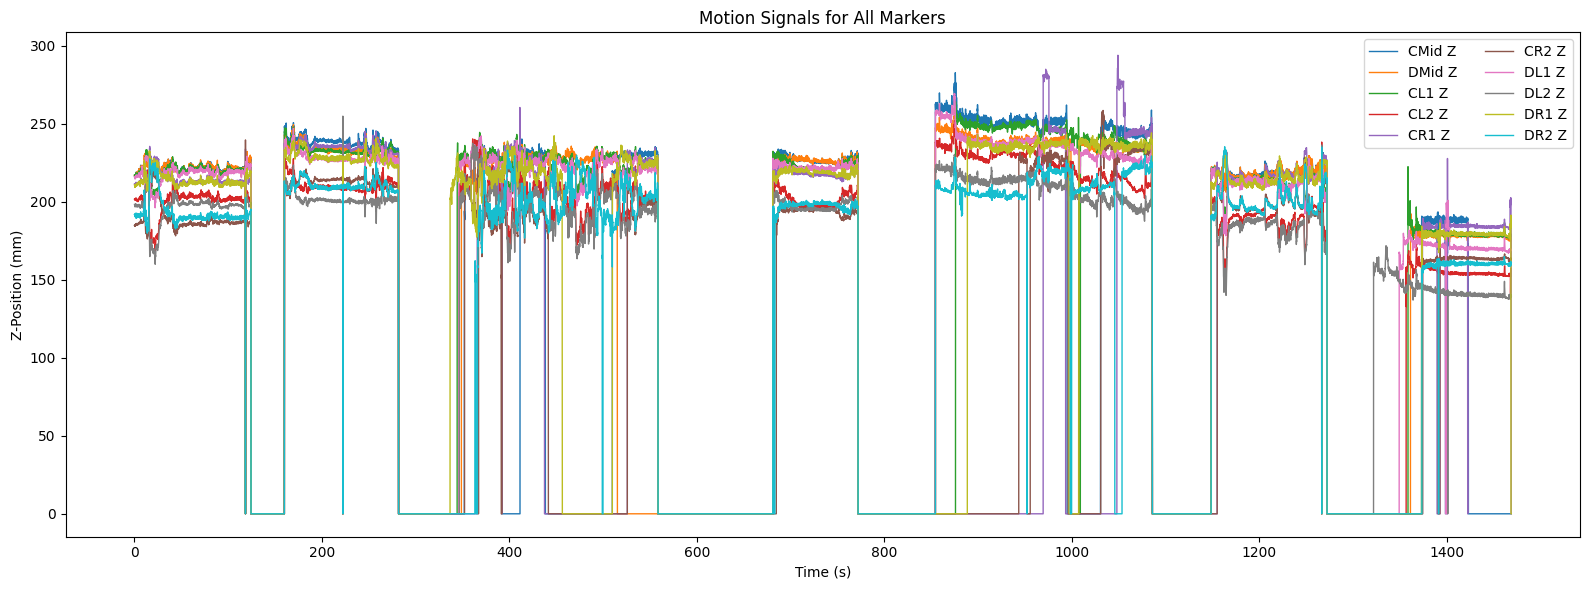

In [105]:
import matplotlib.pyplot as plt
# r = (12000, 17000)  # range of frames to plot
r = (0, motion_signal.shape[1])
t = np.arange(motion_signal.shape[1]) / 100

plt.figure(figsize=(16, 6))
for i, marker in enumerate(expected_motion_columns):
    plt.plot(t[r[0]:r[1]], motion_signal[i, r[0]:r[1]], label=marker, linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Z-Position (mm)")
plt.title("Motion Signals for All Markers")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [117]:
print(f"[MOTION]: {motion_signal.shape[1]} frames | {motion_signal.shape[1] / 100:.2f}s (100Hz)")
print(f"[CO2]: {waveform.shape[0]} frames | {waveform.shape[0] / 20:.2f}s (20Hz)")

[MOTION]: 146883 frames | 1468.83s (100Hz)
[CO2]: 33064 frames | 1653.20s (20Hz)


In [127]:
import numpy as np
from scipy import signal

def align_multirate_sparse_signals(main_sig, joined_sig, fs_main=20, fs_joined=100):
    """
    Aligns a high-rate joined signal (with dead regions) to a low-rate main signal.
    
    Parameters:
        main_sig: np.array (sampled at fs_main)
        joined_sig: np.array (sampled at fs_joined)
        fs_main: The sampling rate of the main signal (e.g., 20)
        fs_joined: The sampling rate of the joined signal (e.g., 100)
    """
    # 1. Downsample Joined Signal (100Hz -> 20Hz)
    # resample_poly is superior to simple slicing as it includes an anti-aliasing filter
    up = 1
    down = fs_joined // fs_main
    joined_resampled = signal.resample_poly(joined_sig, up, down)
    
    # 2. Identify Dead Regions in the resampled signal
    # We treat absolute zeros as 'no data'
    mask = (np.abs(joined_resampled) > 1e-9).astype(float)
    
    # 3. Local Normalization (Zero-Mean)
    # We only subtract the mean of the ACTIVE regions to avoid biasing the signal
    active_indices = mask > 0
    if np.any(active_indices):
        mean_val = np.mean(joined_resampled[active_indices])
        joined_resampled[active_indices] -= mean_val
    
    # 4. Cross-Correlation
    # 'valid' mode ensures the template (joined) fits entirely within the target (main)
    # This returns the correlation at every possible valid shift
    correlation = signal.correlate(main_sig, joined_resampled, mode='valid')
    
    # 5. Energy Normalization (Standardizing the match)
    # We divide by the energy of the main signal under the mask to ensure 
    # amplitude spikes in the main signal don't cause false positives.
    main_sq = main_sig**2
    energy_window = signal.correlate(main_sq, mask, mode='valid')
    # Avoid division by zero
    norm_correlation = correlation / (np.sqrt(energy_window * np.sum(joined_resampled**2)) + 1e-10)
    
    # 6. Extract Best Lag
    best_lag_20hz = np.argmax(norm_correlation)
    
    return best_lag_20hz, norm_correlation

In [ ]:
for i, marker in enumerate(expected_motion_columns):
    candidate = motion_signal[i]
    lag, corr_values = align_multirate_sparse_signals(waveform, candidate)
    print(f"[{marker}] {lag} ({lag / 20:.2f}s)")
    # joined_resampled = signal.resample_poly(candidate, 1, 5)
    # aligned_waveform = waveform[lag : lag + len(joined_resampled)]
    # print(f"[ALIGNED CO2]: {aligned_waveform.shape[0]} frames | {aligned_waveform.shape[0] / 20:.2f}s (20Hz)")

Best lag (in 20Hz frames): 591 (29.55s)
[ALIGNED CO2]: 29377 frames | 1468.85s (20Hz)
